In [ ]:
# Level 6: Final Industry-Style Data Engineering Project

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
.appName("TrainSchedulePipeline") \
.master("local[*]") \
.getOrCreate()

In [3]:
import pandas as pd

df = pd.read_csv("/home/jovyan/work/transformed_data.csv")

stops_table = pd.read_csv("/home/jovyan/work/stops_table.csv")

distance_table = pd.read_csv("/home/jovyan/work/distance_table.csv")

print("All Datasets loaded")

All Datasets loaded


In [5]:
# Task 6.1 - Build a Decision Tree model to predict train journey duration using the prepared dataset

journey_data = df.groupby('Train_No').agg(
    num_stops = ('Station_Name','count'),
    total_distance = ('Distance','max'),
    journey_duration_min = ('journey_duration_min','first')
).reset_index()

print("Features Prepared")
print(journey_data.head())


Features Prepared
   Train_No  num_stops  total_distance  journey_duration_min
0       107          4              78                 105.0
1       108          4              83                 115.0
2       128         22             978                 115.0
3       290         14            2694                 960.0
4       401         12            1618                 690.0


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error,r2_score
import matplotlib as plt
from sklearn import tree

X = journey_data[['num_stops','total_distance']]
Y = journey_data['journey_duration_min']

X_train,X_test,Y_train,Y_test = train_test_split(
    X,Y,test_size = 0.2,random_state = 42)

dt_model = DecisionTreeRegressor(
    max_depth = 4,
    random_state = 42
)
dt_model.fit(X_train,Y_train)

y_pred = dt_model.predict(X_test)

mae = mean_absolute_error(Y_test,y_pred)
r2 = r2_score(Y_test,y_pred)

print("Decision Tree Model Built")
print("=" * 40)
print("Model Performance:")
print("Training Size:", len(X_train))
print("Testing Size:", len(X_test))
print("Mean Absolute Error:", round(mae, 2))
print("R2 Score:", round(r2, 2))
print("=" * 40)

Decision Tree Model Built
Model Performance:
Training Size: 8890
Testing Size: 2223
Mean Absolute Error: 95.66
R2 Score: 0.5


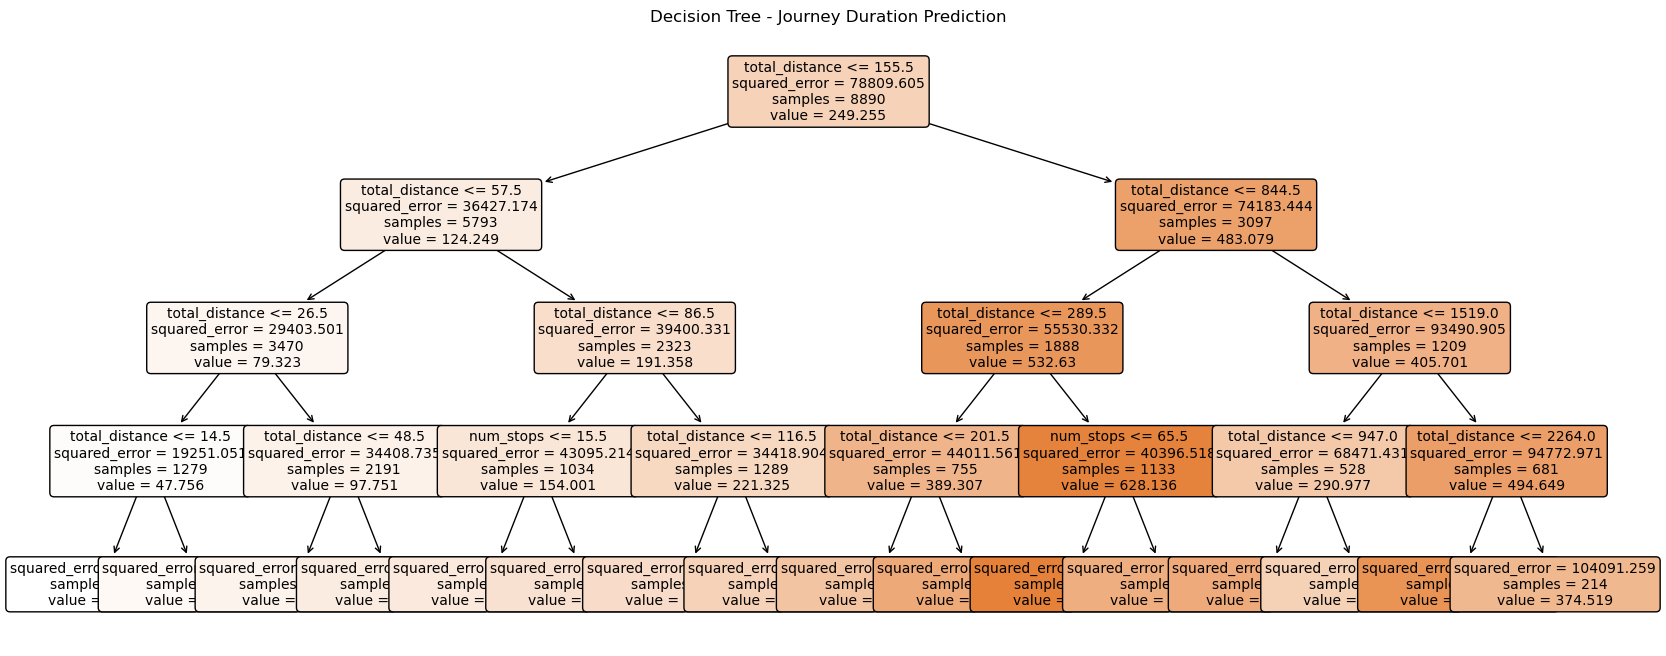

In [12]:
# Visualize Decision Tree

import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize = (20,8))
tree.plot_tree(
    dt_model,
    feature_names = ['num_stops','total_distance'],
    filled = True,
    rounded = True,
    fontsize = 10
)

plt.title("Decision Tree - Journey Duration Prediction")
plt.savefig("/home/jovyan/work/decision_tree.png")
plt.show()